In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import sys
import localSettings as ls
import math
print(ls.main_path)
import load_data_run123
import plotter_alex
import importlib
importlib.reload(plotter_alex)
import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import pickle
import xgboost as xgb
import nue_booster 
importlib.reload(nue_booster)
import awkward
from matplotlib import gridspec
from collections import defaultdict

/home/alex/NuMI/PELEE/


In [2]:
ending = "Jan19b"

In [3]:
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_events_energy_MC_ONLY_weighted_recoCut_incErr_MECTune_'+ending+'.csv') as file:
    content = file.readlines()
events = content[0:]
    
for i in range(12):
    events[i]=events[i].rstrip().rstrip(',')
    events[i] = float(events[i])
    
print("Unsmeared events")
print(events)
print("")

nuWro_events = events

#------------------------------------------------------------------------------
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_AC_energy_MC_ONLY_weighted_recoCut_incErr_MECTune_'+ending+'.csv') as file:
    content = file.readlines()
AC = content[0:]
    
for i in range(144):
    AC[i]=AC[i].rstrip().rstrip(',')
    AC[i] = float(AC[i])
    

chunks = [AC[x:x+12] for x in range(0, len(AC), 12)]

print("AC")
print(chunks)
nuWro_Ac = chunks
print("")
#---------------------------------------------------------------

with open('nue_full_500_catsel_nopions_recoE_usingSelection_prior_true_signal_blockwise_recoCut_comb_'+ending+'.csv') as file:
    content = file.readlines()
prior_true = content[0:]
    
for i in range(12):
    prior_true[i]=prior_true[i].rstrip().rstrip(',')
    prior_true[i] = float(prior_true[i])
    
print("Prior Truth: ")
print(prior_true)
print("")

prior_true_nuWro = prior_true

#----------------------------------------------------------------
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_errors_energy_MC_ONLY_weighted_recoCut_incErr_MECTune_'+ending+'.csv') as file:
    content = file.readlines()
errs = content[0:]
    
for i in range(12):
    errs[i]=errs[i].rstrip().rstrip(',')
    errs[i] = float(errs[i])
    
print("Errors: ")
print(errs)
print("")
print("################################################################")
print("")

nuWro_errs = errs

#----------------------------------------------------------------
with open('../blockwise/stv-analysis-new/blockwise_unsmeared_cov_matrix_energy_MC_ONLY_weighted_recoCut_incErr_MECTune_'+ending+'.csv') as file:
    content = file.readlines()
cov = content[0:]
    
for i in range(144):
    cov[i]=cov[i].rstrip().rstrip(',')
    cov[i] = float(cov[i])
    

chunks_cov = [cov[x:x+12] for x in range(0, len(cov), 12)]

print("cov")
print(chunks_cov)
print("")

Unsmeared events
[257.118, 594.47, 403.8, 162.866, 62.4104, 99.4696, 6406.51, 11267.1, 7884.71, 2978.73, 347.323, 108.905]

AC
[[0.80273, 0.186879, -0.0688653, -0.0481077, 0.0758894, -0.176556, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.186879, 0.66252, 0.17968, 0.185441, 0.017296, 0.0231775, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [-0.0688653, 0.17968, 0.666889, 0.0651957, -0.06733, 0.163238, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [-0.0481077, 0.185441, 0.0651957, 0.0969874, 0.000674099, 0.0594639, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0758894, 0.017296, -0.06733, 0.000674099, 0.474328, 0.249692, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [-0.176556, 0.0231775, 0.163238, 0.0594639, 0.249692, 0.263278, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.681613, 0.339308, -0.186204, -0.187657, -0.0209216, -0.00489942], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.339308, 0.524637, 0.269803, 0.172797, 0.0216187, 0.00673967], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.186204, 0.269803, 0.758097, 0.00904536, -0.00770882, -0.00271287], [0.0

In [4]:
with open('../blockwise/stv-analysis-new/blocks_12.txt') as file:
    content = file.readlines()
blocks = content[0:]

print(blocks)

['12\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  1\n', '7  1\n', '8  1\n', '9  1\n', '10 1\n', '11 1\n', '12\n', '0  0\n', '1  0\n', '2  0\n', '3  0\n', '4  0\n', '5  0\n', '6  1\n', '7  1\n', '8  1\n', '9  1\n', '10 1\n', '11 1\n']


In [5]:

made_data_sig = np.dot(prior_true, chunks)
print("Prior_Truth x AC: ")
print(made_data_sig)
print("")
print("")
print("Unfolding Done with MC Data Signal: ")
print(events)
print("")

diff = made_data_sig - events
print("")
print("Difference")
print(diff)


print("")
diffasfrac = np.nan_to_num(diff/made_data_sig)
print(diffasfrac*100)

Prior_Truth x AC: 
[ 219.679291    457.11589403  298.98378305  122.33417249   55.41852657
   72.14453231 5348.08429491 8987.20719996 5982.31588117 2335.27555384
  269.45100581   85.19649705]


Unfolding Done with MC Data Signal: 
[257.118, 594.47, 403.8, 162.866, 62.4104, 99.4696, 6406.51, 11267.1, 7884.71, 2978.73, 347.323, 108.905]


Difference
[  -37.438709    -137.35410597  -104.81621695   -40.53182751
    -6.99187343   -27.32506769 -1058.42570509 -2279.89280004
 -1902.39411883  -643.45444616   -77.87199419   -23.70850295]

[-17.04243893 -30.04798296 -35.05749238 -33.13205679 -12.61649101
 -37.87545198 -19.79074462 -25.36820115 -31.80029535 -27.55368398
 -28.90024254 -27.82802553]


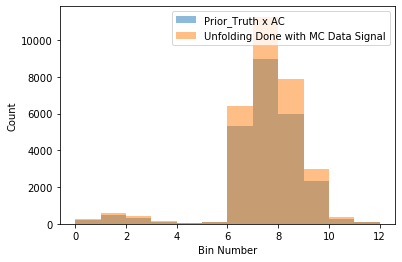

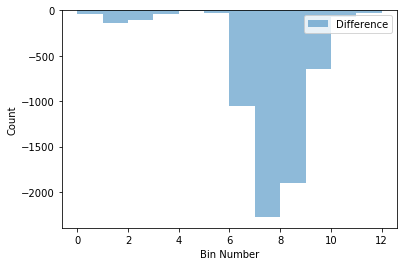

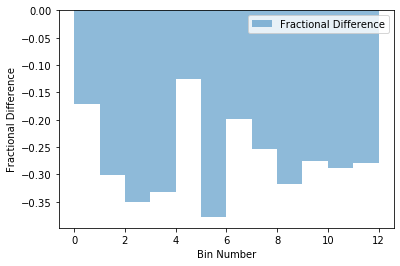

In [6]:
import random
import numpy
from matplotlib import pyplot

bins = np.arange(0, 13, 1)
count = np.arange(0.0, 12.0, 1)

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()

pyplot.hist(count, bins, weights=diff, alpha=0.5, label='Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.show()


pyplot.hist(count, bins, weights=diffasfrac, alpha=0.5, label='Fractional Difference')
pyplot.legend(loc='upper right')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Fractional Difference")
pyplot.show()

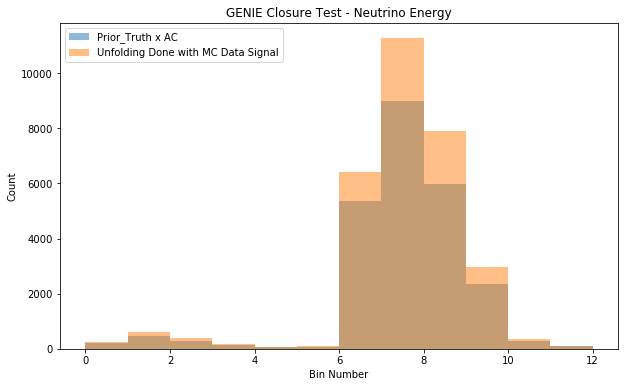

In [7]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=made_data_sig, alpha=0.5, label='Prior_Truth x AC')
pyplot.hist(count, bins, weights=events, alpha=0.5, label='Unfolding Done with MC Data Signal')
pyplot.legend(loc='upper left')
pyplot.xlabel("Bin Number")
pyplot.ylabel("Count")
pyplot.title("GENIE Closure Test - Neutrino Energy")
pyplot.show()

#fig.savefig("MECTune_fakeData_closure_test_energy_"+ending+".svg",bbox_inches='tight' )


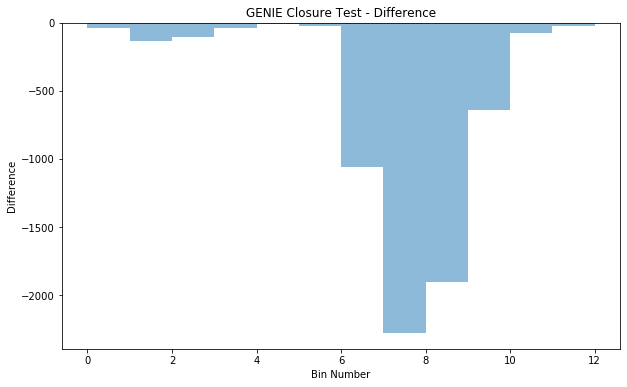

In [8]:
fig = plt.figure(figsize=(10, 6))

pyplot.hist(count, bins, weights=diff, alpha=0.5)
pyplot.xlabel("Bin Number")
pyplot.ylabel("Difference")
pyplot.title("GENIE Closure Test - Difference")
pyplot.show()

#fig.savefig("MECTune_fakeData_closure_test_diff_energy_"+ending+".svg",bbox_inches='tight' )

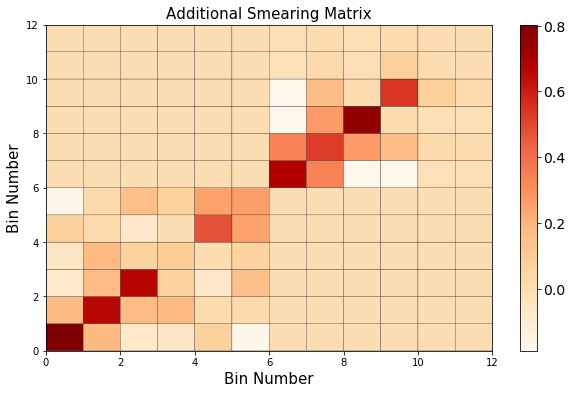

In [9]:
fig = plt.figure(figsize=(10, 6))  
    
plt.pcolor(bins, bins, chunks, cmap='OrRd', edgecolors='k')
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title('Additional Smearing Matrix', fontsize=15)

plt.show()

fig.savefig("MECTune_fakeData_closure_test_Ac_energy_"+ending+".svg",bbox_inches='tight' )

/tmp/ipykernel_11756/632254931.py:7: RuntimeWarning: invalid value encountered in log
  plt.pcolor(bins, bins, np.log(chunks_cov), cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)


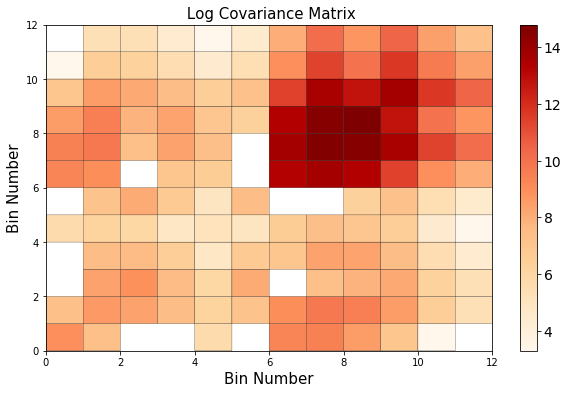

In [10]:
fig = plt.figure(figsize=(10, 6))  

bins = np.arange(0, 13, 1)
count = np.arange(0.0, 12.0, 1)
    
plt.pcolor(bins, bins, np.log(chunks_cov), cmap='OrRd', edgecolors='k')
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Log Covariance Matrix', fontsize=15)

plt.show()

In [11]:
np.savetxt("data_covmat_MC_MECTune_chi2_recoE_comb_"+ending+".csv", 
           chunks_cov,
           delimiter =", ", 
           fmt ='% s')

print(ending)

Jan19b


## Actual comparison needed

Need to compare the unfolded signal w/err to the nuWro true selected signal x Ac

In [12]:
print(nuWro_events)
print(nuWro_errs)

[257.118, 594.47, 403.8, 162.866, 62.4104, 99.4696, 6406.51, 11267.1, 7884.71, 2978.73, 347.323, 108.905]
[88.3005, 76.8069, 87.6654, 26.5998, 12.8871, 42.298, 789.435, 1558.78, 1639.82, 958.048, 127.29, 36.9164]


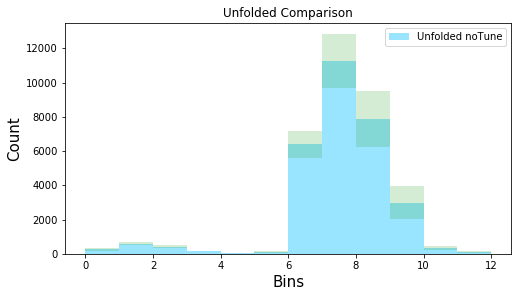

In [13]:
###############
###BOTH######
#############

nue_unf_fig = plt.figure(figsize=(8, 7))
nue_unf_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_unf_ax1 = plt.subplot(nue_unf_gs[0])


bins = np.arange(0, 13, 1)
count = np.arange(0.0, 12.0, 1)
bincenters = np.arange(0.5, 12.5, 1)
bin_size = [0.5]*12

sel = nue_unf_ax1.hist(count, bins, color='deepskyblue', weights=nuWro_events, alpha = 0.4, label="Unfolded noTune")  # , weights=xsec_ratio_events

errors = nue_unf_ax1.bar(bincenters, np.array(nuWro_errs)*2,width=[n*2 for n in bin_size],facecolor='tab:green',alpha=0.2,bottom=(np.array(nuWro_events) - np.array(nuWro_errs)))


nue_unf_ax1.set_ylabel('Count', fontsize=15)
nue_unf_ax1.set_xlabel('Bins', fontsize=15)
nue_unf_ax1.set_title("Unfolded Comparison")
leg = nue_unf_ax1.legend()

In [14]:
ending = "Jan19b_MECTune"

nue_nuWro_true = pd.read_csv("nue_full_500_catsel_nopions_recoE_usingSelection_prior_true_signal_MECTune_recoCut_comb_"+ending+".csv", header=None)

nue_nuWro_true = nue_nuWro_true.values[:, 0]
print(nue_nuWro_true)
print("")
#########################################

numu_nuWro_true = pd.read_csv("numu_full_500_catsel_nopions_recoE_usingSelection_prior_true_signal_MECTune_recoCut_comb_"+ending+".csv", header=None)

numu_nuWro_true = numu_nuWro_true.values[:, 0]
print(numu_nuWro_true)

[250.9467516  617.85717364 374.05631823 157.55216652  78.73690158
  91.70039948]

[ 6809.51648446 11611.743303    7075.40344288  3360.32059263
  1568.42878441  2893.38754544]


In [16]:
nue_numu_tot_nuWro_true = np.concatenate((nue_nuWro_true, numu_nuWro_true), axis=0)

print(nue_numu_tot_nuWro_true)

[  250.9467516    617.85717364   374.05631823   157.55216652
    78.73690158    91.70039948  6809.51648446 11611.743303
  7075.40344288  3360.32059263  1568.42878441  2893.38754544]



In [17]:
#Now smear it by Ac

smeared_nuWro = np.dot(nue_numu_tot_nuWro_true, nuWro_Ac)
print("Prior_Truth x AC: ")
print(smeared_nuWro)
print("")
print("")
print("Unfolding Done with MC Data Signal: ")
print(nuWro_events)
print("")

diff = smeared_nuWro - events
print("")
print("Difference")
print(diff)

print("")
diffasfrac = np.nan_to_num(diff/smeared_nuWro)
print(diffasfrac*100)

Prior_Truth x AC: 
[  273.35308422   556.15370271   363.12845565   147.67695945
    64.89562314    84.24577372  6586.36629159 10945.49985171
  7239.22128477  2787.29248827   321.24298958   101.88846136]


Unfolding Done with MC Data Signal: 
[257.118, 594.47, 403.8, 162.866, 62.4104, 99.4696, 6406.51, 11267.1, 7884.71, 2978.73, 347.323, 108.905]


Difference
[  16.23508422  -38.31629729  -40.67154435  -15.18904055    2.48522314
  -15.22382628  179.85629159 -321.60014829 -645.48871523 -191.43751173
  -26.08001042   -7.01653864]

[  5.93923579  -6.88951581 -11.20031871 -10.28531506   3.82956972
 -18.07072997   2.73073625  -2.93819517  -8.91654903  -6.86822472
  -8.11846835  -6.88648994]


unfolded =  [  257.118    594.47     403.8      162.866     62.4104    99.4696
  6406.51   11267.1     7884.71    2978.73     347.323    108.905 ]
smeared =  [  273.35308422   556.15370271   363.12845565   147.67695945
    64.89562314    84.24577372  6586.36629159 10945.49985171
  7239.22128477  2787.29248827   321.24298958   101.88846136]


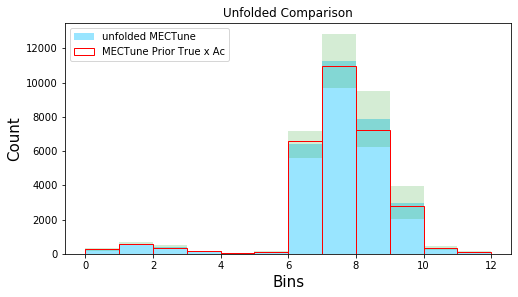

In [19]:
###############
###NUE######
#############

nue_unf_fig = plt.figure(figsize=(8, 7))
nue_unf_gs = gridspec.GridSpec(2, 1, height_ratios=[2, 1])
nue_unf_ax1 = plt.subplot(nue_unf_gs[0])


bins = np.arange(0, 13, 1)
count = np.arange(0.0, 12.0, 1)
bincenters = np.arange(0.5, 12.5, 1)
bin_size = [0.5]*12

f_obs = nue_unf_ax1.hist(count, bins, color='deepskyblue', weights=nuWro_events, alpha = 0.4, label="unfolded MECTune")  # , weights=xsec_ratio_events

errors = nue_unf_ax1.bar(bincenters, np.array(nuWro_errs)*2,width=[n*2 for n in bin_size],facecolor='tab:green',alpha=0.2,bottom=(np.array(nuWro_events) - np.array(nuWro_errs)))

f_exp = nue_unf_ax1.hist(count, bins, edgecolor='red', facecolor='None', weights=smeared_nuWro, label='MECTune Prior True x Ac')

print("unfolded = ", f_obs[0])
print("smeared = ", f_exp[0])

nue_unf_ax1.set_ylabel('Count', fontsize=15)
nue_unf_ax1.set_xlabel('Bins', fontsize=15)
nue_unf_ax1.set_title("Unfolded Comparison")
leg = nue_unf_ax1.legend()


nue_unf_fig.savefig("unfolded_MC_MECTune_output_recoE_comb_"+ending+".svg", bbox_inches='tight')

In [20]:
np.savetxt("data_signal_MC_MECTune_chi2_recoE_comb_"+ending+".csv", 
               nuWro_events,
               delimiter =", ", 
               fmt ='% s')

np.savetxt("prior_true_MC_MECTune_chi2_recoE_comb_"+ending+".csv", 
               smeared_nuWro,
               delimiter =", ", 
               fmt ='% s')

print(ending)

Jan19b_MECTune


In [22]:
for i in np.arange(len(smeared_nuWro)):
    print("bin = ", i)
    if( ((smeared_nuWro[i] < nuWro_events[i] + nuWro_errs[i]) and (smeared_nuWro[i] > nuWro_events[i] - nuWro_errs[i]))): #or ((nuWro_events[i] < smeared_nuWro[i] + nue_numu_tot_nuWro_true_err[i]) and (nuWro_events[i] > smeared_nuWro[i] - nue_numu_tot_nuWro_true_err[i])) ):
        print("Inside")
        print("")
    else:
        print("outside")
        print("value is (genie) = ", smeared_nuWro[i])
        print("top of err = ", nuWro_events[i] + nuWro_errs[i])
        print("bot of err = ", nuWro_events[i] - nuWro_errs[i])
        print("")

bin =  0
Inside

bin =  1
Inside

bin =  2
Inside

bin =  3
Inside

bin =  4
Inside

bin =  5
Inside

bin =  6
Inside

bin =  7
Inside

bin =  8
Inside

bin =  9
Inside

bin =  10
Inside

bin =  11
Inside



In [23]:
f_obs = f_obs[0]
f_exp = f_exp[0]

In [24]:
hold = []

for i in range(12):
    braket = (f_obs[i] - f_exp[i])
    num = (braket*braket)/f_exp[i]
    hold.append(num)
    
print(sum(hold))
chi_squared_stat = sum(hold)

100.23266832821267


In [25]:
####Crital value - what the chi sqaured value must be below for a P value fo this significance
import scipy.stats as sp

deg_of_free = 11*11

sp.chi2.ppf(q = 0.05, df = deg_of_free)

96.59848202649013

In [26]:
p_value = 1 - sp.chi2.cdf(x=chi_squared_stat,  # Find the p-value
                             df=deg_of_free)
print("P value:",p_value)

P value: 0.9156707017958845


In [27]:
####It's a really good value up until 19, but adding bin 20 kicks it out

## Values from Steven's Code which takes uncertainty into account

In [28]:
sp.chi2.ppf(q = 0.5, df = 11)

10.340998074391827

In [29]:
####################################

In [30]:
inverse_unfcov = np.linalg.inv(chunks_cov)

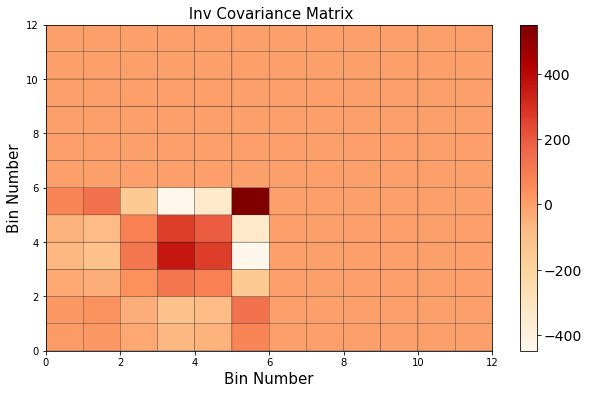

In [31]:
fig = plt.figure(figsize=(10, 6))  

bins = np.arange(0, 13, 1)
count = np.arange(0.0, 12.0, 1)
    
plt.pcolor(bins, bins, inverse_unfcov , cmap='OrRd', edgecolors='k')#, vmin=-1, vmax=1)
            
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)

plt.xlabel('Bin Number', fontsize=15)
plt.ylabel('Bin Number', fontsize=15)

plt.title(' Inv Covariance Matrix', fontsize=15)

plt.show()

In [32]:
chi2_genie = 0

print(len(bins)-1)
print(len(f_obs))

for i in range(len(bins)-1): 
    
    for j in range(len(f_obs)): 

            
            chi2_genie = chi2_genie  + ( (f_obs[i]-f_exp[i])*inverse_unfcov[i][j]*(f_obs[j]-f_exp[j]) )
  

12
12


In [33]:
chi2_genie

1.4925094855563543

In [34]:
p_value = 1 - sp.chi2.cdf(x=chi2_genie,  # Find the p-value
                             df=19)
print("P value:",p_value)

P value: 0.9999999720874931
